<a href="https://colab.research.google.com/github/MiguelAnthonyTi/Perceptron/blob/main/Rede_Neurais_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn.datasets import load_breast_cancer # Sklearn é uma Biblioteca famosa com diversos bancos de dados para praticar
from sklearn.model_selection import train_test_split # train_test_split Vamos dividir os dados
from sklearn.preprocessing import StandardScaler # Fazem com que numeros muito grandes não ofusquem os menores
from sklearn.neural_network import MLPClassifier # Matematica da Rede Neural
from sklearn.metrics import accuracy_score, classification_report # metricas para ver qual a % de acerto da IA


data = load_breast_cancer()
X = data.data
y = data.target

print(X)
print(y)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


# Normalizando os dados - Redes neurais tem mais eficiencia com dados normalizados
# Por que se eu fizer as contas dos pesos sem normalizar sempre o maior peso ira predominar

scaler = StandardScaler ()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Criando o Modelo
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000, random_state=42)


#treinando o Modelo
mlp.fit(X_train_scaled, y_train)


y_pred =mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acuracia do MOdelo: {accuracy:.2f}")
print("\nRelatorio de Classifucação:\n")
print(classification_report(y_test,y_pred))
print()



[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

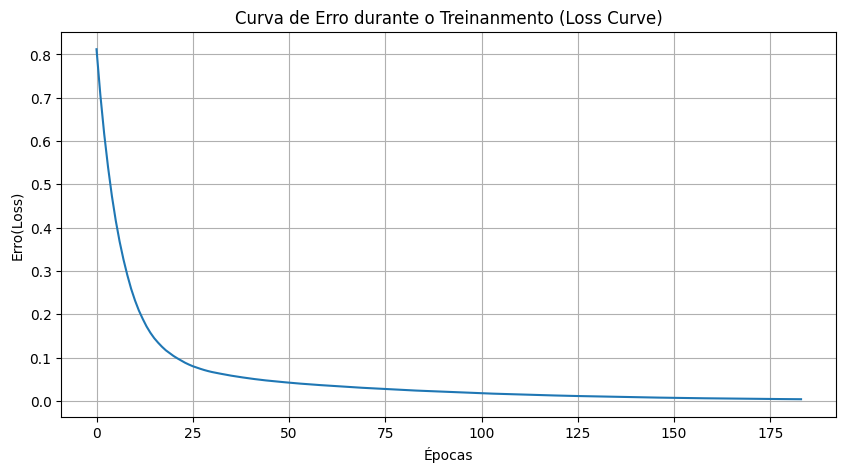

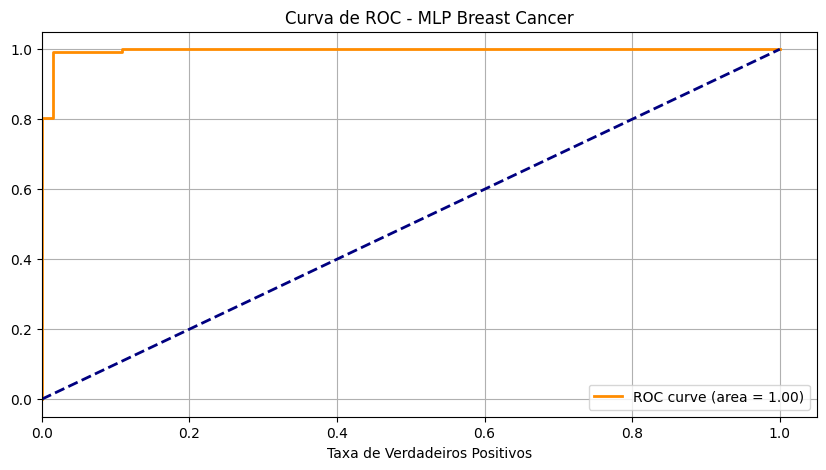

Relatorio de Classificação

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.97        64
      benign       0.99      0.97      0.98       107

    accuracy                           0.98       171
   macro avg       0.97      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc, classification_report, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

data = load_breast_cancer()
X = data.data
y = data.target

print(data.DESCR)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Criando o MLP
mlp = MLPClassifier (hidden_layer_sizes=(100,50), max_iter=500,
                     activation='relu',solver='adam',
                     random_state=42, verbose=False)

mlp.fit(X_train_scaled, y_train)


#Criação para Visualizar os erros (Curva de Loss)
plt.figure(figsize=(10,5))
plt.plot(mlp.loss_curve_)
plt.title("Curva de Erro durante o Treinamento (Loss Curve)")
plt.xlabel("Épocas")
plt.ylabel("Erro(Loss)")
plt.grid(True)
plt.show()

#Criação para visualizar o GRafico (AUC-ROC)

y_pred_proba = mlp.predict_proba(X_test_scaled)[:,1]
frp, trp, thresholds = roc_curve(y_test,y_pred_proba)
roc_auc = auc(frp,trp)


plt.figure(figsize=(10,5))
plt.plot(frp,trp,color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle= '--')
plt.xlim([0.0,1.0])
plt.xlim([0.0,1.05])
plt.xlabel("Taxa de Falsos Positivos")
plt.xlabel("Taxa de Verdadeiros Positivos")
plt.title("Curva de ROC - MLP Breast Cancer")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



y_pred = mlp.predict(X_test_scaled)
print("Relatorio de Classificação\n")
print(classification_report(y_test,y_pred,target_names=data.target_names))



